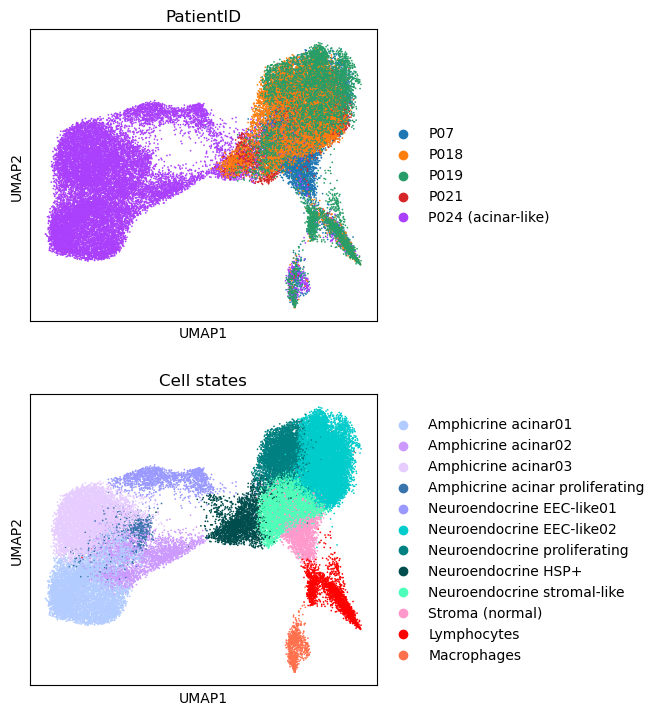

In [1]:
import scanpy as sc
import pandas as pd
import os

adata= sc.read_h5ad("./celltypist_benchmark/pNEC_updated_annot_07082023.h5ad")

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']= (4,4)

sc.pl.umap(adata, color= ['PatientID', 'Cell states'], size=6, ncols=1)

In [2]:
#Rename PatientID labels
adata.obs['PatientID'] = adata.obs['PatientID'].replace({
    'P07': 'P1',
    'P018': 'P2',
    'P019': 'P3',
    'P021': 'P4',
    'P024 (acinar-like)': 'P5 (acinar)'
})


print(adata.obs['PatientID'].value_counts()) 

#Rename Cell states labels
adata.obs['Cell states'] = adata.obs['Cell states'].replace({
    'Neuroendocrine EEC-like01': 'Amphicrine progenitor-like',
    'Neuroendocrine EEC-like02': 'Neuroendocrine',
    'Neuroendocrine HSP+': 'Neuroendocrine HSP+ (hypoxic)'
})

print(adata.obs['Cell states'].value_counts()) 

PatientID
P5 (acinar)    19497
P1              8768
P2              8314
P3              5580
P4              2856
Name: count, dtype: int64
Cell states
Neuroendocrine                     10095
Amphicrine acinar01                 7047
Amphicrine acinar03                 5840
Neuroendocrine stromal-like         5668
Neuroendocrine proliferating        4033
Stroma (normal)                     2465
Amphicrine acinar02                 2424
Neuroendocrine HSP+ (hypoxic)       2275
Lymphocytes                         2124
Amphicrine progenitor-like          1488
Macrophages                          821
Amphicrine acinar proliferating      735
Name: count, dtype: int64


/tmp/ipykernel_204779/1365199625.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['PatientID'] = adata.obs['PatientID'].replace({
/tmp/ipykernel_204779/1365199625.py:14: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['Cell states'] = adata.obs['Cell states'].replace({


NEURONAL + PROLIFERATION MARKERS ACROSS P1-P4

Total cells (P1-P4, NE only): 20604
Total genes available: 32873
Cell states: ['Neuroendocrine', 'Neuroendocrine proliferating', 'Neuroendocrine stromal-like', 'Neuroendocrine HSP+ (hypoxic)']
Categories (4, object): ['Neuroendocrine', 'Neuroendocrine proliferating', 'Neuroendocrine HSP+ (hypoxic)', 'Neuroendocrine stromal-like']
Patients: ['P1', 'P4', 'P2', 'P3']
Categories (4, object): ['P1', 'P2', 'P3', 'P4']

Genes available: ['RBFOX1', 'RIMBP2', 'ADARB2', 'CACNA1A', 'CACNB2', 'KCNB2', 'KCNJ6']

Plotting P1...
  P1 cells: 5895
  Cell states: {'Neuroendocrine stromal-like': 2815, 'Neuroendocrine': 2251, 'Neuroendocrine proliferating': 737, 'Neuroendocrine HSP+ (hypoxic)': 92}

Plotting P2...
  P2 cells: 7851
  Cell states: {'Neuroendocrine': 3655, 'Neuroendocrine proliferating': 2075, 'Neuroendocrine stromal-like': 1640, 'Neuroendocrine HSP+ (hypoxic)': 481}

Plotting P3...
  P3 cells: 4072
  Cell states: {'Neuroendocrine': 2685, 'Neuro

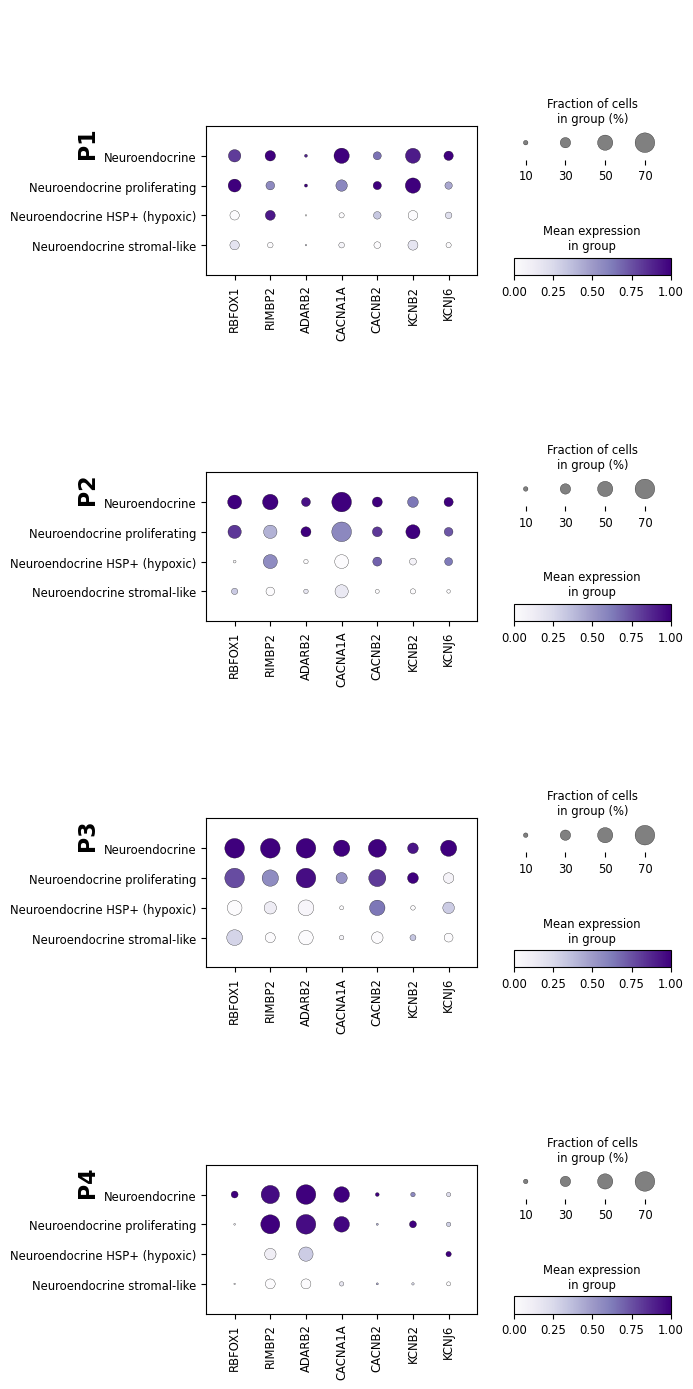


 Figure saved!
Files generated:
  - ./figures/Reviewer_Fig_neuronal_brain_markers_P1-P4_27112025.pdf
  - ./figures/Reviewer_Fig_neuronal_brain_markers_P1-P4_27112025.png


In [3]:
import matplotlib.pyplot as plt

print("="*80)
print("NEURONAL + PROLIFERATION MARKERS ACROSS P1-P4")
print("="*80)

#Use raw anndata- contains all genes 
if adata.raw is not None:
    adata_raw = adata.raw.to_adata()
    adata_raw.obs = adata.obs.copy()  #Copy annotations
else:
    adata_raw = adata.copy()

#Filter to P1-P4 only, NE sub-populations only
adata_p1_p4 = adata_raw[adata_raw.obs['PatientID'].isin(['P1', 'P2', 'P3', 'P4'])].copy()
adata_ne = adata_p1_p4[adata_p1_p4.obs['Cell states'].str.contains('Neuroendocrine')].copy()

print(f"\nTotal cells (P1-P4, NE only): {adata_ne.n_obs}")
print(f"Total genes available: {adata_ne.n_vars}")
print(f"Cell states: {adata_ne.obs['Cell states'].unique()}")
print(f"Patients: {adata_ne.obs['PatientID'].unique()}")

#Selected brain + neuronal markers
neuronal_markers = ['RBFOX1', 'RIMBP2', 'ADARB2', 'CACNA1A', 'CACNB2', 'KCNB2', 'KCNJ6']

#Combine markers
all_markers = neuronal_markers 

#Check which markers are present
genes_available = [gene for gene in all_markers if gene in adata_ne.var_names]
genes_missing = [gene for gene in all_markers if gene not in adata_ne.var_names]

print(f"\nGenes available: {genes_available}")
if genes_missing:
    print(f"Genes missing: {genes_missing}")

#Create stacked dotplots per patient
patients = ['P1', 'P2', 'P3', 'P4']

fig, axes = plt.subplots(len(patients), 1, figsize=(7, 3.5*len(patients)))

for idx, patient in enumerate(patients):
    print(f"\nPlotting {patient}...")
    adata_patient = adata_ne[adata_ne.obs['PatientID'] == patient].copy()
    
    print(f"  {patient} cells: {adata_patient.n_obs}")
    print(f"  Cell states: {adata_patient.obs['Cell states'].value_counts().to_dict()}")
    
    ax = axes[idx]
    
    sc.pl.dotplot(
        adata_patient,
        var_names=genes_available,
        groupby='Cell states',
        standard_scale='var',
        dot_max=0.7,
        cmap='Purples',
        ax=ax,
        show=False
    )
    
    #Add patient label
    ax.text(-0.28, 0.5, patient, transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='center', rotation=90)

plt.tight_layout()
plt.savefig('./figures/Reviewer_Fig_neuronal_prol_markers_P1-P4.pdf', bbox_inches='tight', dpi=300)
plt.savefig('./figures/Reviewer_Fig_neuronal_prol_markers_P1-P4.png', bbox_inches='tight', dpi=300)
plt.show()

print("\n Figure saved!")
print("Files generated:")
print("  - ./figures/Reviewer_Fig_neuronal_brain_markers_P1-P4_27112025.pdf")
print("  - ./figures/Reviewer_Fig_neuronal_brain_markers_P1-P4_27112025.png")